#  Hyperparameter Tuning for CNN Image Classification — Dogs vs Cats



This project investigates how hyperparameter tuning affects the performance of a CNN trained on a real world binary image classification task.
#overview of project

i have tried to share everything i tried to tune and get descent accuracy starting from without any help of tools and eventually evolving towards it trying to find out whats the best approach to do so i have notes my observations for all the cases.

Rather than jumping straight to automated tools, this notebook takes a
structured approach starting from a baseline model with default parameters,
then experimenting manually to understand what each hyperparameter actually
does, and finally using Optuna (a Bayesian optimization framework) to
systematically search for the best configuration.

## What this notebook covers
- **Baseline model** — a CNN trained with no tuning, as a reference score setting the baseline
- **Manual tuning** — one-parameter at a time experiments (learning rate, dropout, filters) checking which parameter can significantly get me a better score
- **Optuna tuning** — automated search across 20 trials with early stopping
- **Comparison** — all three approaches side by side with analysis

 at the end i have also jotted down my observations while telling which approach is the best in what cases


 # What Actually Improves CNN Performance? An Empirical Study on the Stanford Dogs Dataset

This project started as an attempt to get the best possible accuracy
on a 120 breed dog classification problem and somewhere along the
way turned into something more interesting: figuring out what actually
moves the needle and what doesn't.

Every technique is tested in isolation so the impact is clear.
No hand-waving — just results.

---

# Overview

Rather than jumping straight to transfer learning or automated tools, I worked through this project in deliberate layers. Every decision is justified by an experiment that came before it. The goal wasn't just to get good accuracy — it was to understand *why* each change helps or doesn't, and to document that honestly.

Each phase lives in its own notebook so the progression is easy to follow.

---

# What This Project Covers

## 1. Data + Baseline

- Dataset exploration and visualization
- Normalization experiment — what breaks without normalization vs with it
- A reference CNN with:
  - valid padding
  - no regularization
  - no augmentation
  - no tuning tricks
- Result:
  - severe overfitting
  - ~ 5.3 validation accuracy

This notebook establishes the baseline every later improvement is compared against.

---

## 2. Input Size Experiments

The same baseline model is trained at:

- 64×64
- 128×128
- 224×224

Compared on:
- validation accuracy
- training time
- parameter count

### Conclusion
128×128 offered the best tradeoff between compute cost and performance, so it became the standard resolution for future experiments.

---

## 3. Architecture Experiments

Different CNN design choices were isolated and tested individually.

### Experiment A — Batch Normalization
Does stabilizing activation distributions improve convergence and validation accuracy?

### Experiment B — Flatten vs GlobalAveragePooling
Comparing:
- Flatten → ~14M parameters
- GlobalAveragePooling → ~500K parameters

Question:
Can reducing parameter count reduce overfitting without hurting performance?

### Experiment C — Convolutional Depth
2 vs 3 vs 4 convolutional blocks.

Question:
At what point does adding layers stop helping?

### Experiment D — Filter Progression
Comparing:
- 32 → 64 → 128
- 64 → 128 → 256

Question:
How much performance gain is worth the additional compute cost?

---

## 4. Regularization Experiments

### Experiment E — Dropout
Tested:
- 0.2
- 0.3
- 0.5

Question:
How much dropout is useful before the model starts underfitting?

### Experiment F — L2 Regularization
Compared:
- none
- 1e-4
- 1e-3

Question:
Does penalizing large weights improve generalization?

### Experiment G — Data Augmentation
Compared:
- no augmentation
- basic augmentation
- strong augmentation

### Key Observation
Data augmentation became the single most effective fix for overfitting.

---

## 5. How Much Does Hyperparameter Tuning Actually Matter?
Once the architecture was stable, hyperparameters were tuned one at
a time. This section shows that tuning matters but less than most
people think. Architecture and regularization choices made in
notebooks 3 and 4 had more impact than any learning rate sweep.

### Experiment H — Learning Rate
Compared:
- 0.01
- 0.001
- 0.0001

### Observation
Learning rate had the largest impact on convergence quality and training stability.

### Experiment I — Batch Size
Compared:
- 16
- 32
- 64
- 128

Question:
How does batch size affect:
- speed
- memory usage
- gradient stability
- generalization?

### Experiment J — Optimizer
Compared:
- Adam
- SGD
- RMSprop

Question:
Which optimizer converges fastest, and which generalizes best?

---

## 6. Optuna Hyperparameter Tuning

Automated tuning using:

- TPE Sampler
- MedianPruner
- 20 trials
- 8 epochs per trial

### Includes
- optimization history
- parameter importance plots
- contour visualizations

### Final Comparison
Best Optuna configuration vs best manually tuned configuration.

---

## 7. Transfer Learning

This section explores why pretrained CNNs dominate practical computer vision tasks.

### MobileNetV2 — Feature Extraction
- frozen pretrained base
- custom classification head

### MobileNetV2 — Fine Tuning
- unfreezing the final layers
- adapting pretrained features to dog breeds

### Result
Validation accuracy jumps from:
- ~15% (best scratch CNN)
to
- ~75–80% using transfer learning

This gap demonstrates why pretrained representations are so powerful in deep learning.

### Also Discussed
Cases where transfer learning may not work well:
- medical X-rays
- satellite imagery
- industrial inspection data

---

## 8. Final Comparison + Conclusions

### Includes
- every experiment on a single comparison chart
- learning curve across notebooks
- misclassified image analysis
- validation accuracy vs training cost comparisons

### Final Conclusions
- what improved performance the most
- what turned out to be overhyped
- what I would change if rebuilding the project from scratch

---

# Tech Stack

- Python
- TensorFlow / Keras
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Optuna
- Google Colab

---

# Key Takeaway

This project started with a deliberately weak CNN that severely overfit the dataset and gradually evolved through controlled experimentation, manual tuning, and transfer learning.

The main goal was not just achieving higher accuracy, but understanding which deep learning techniques genuinely matter — and why.

### Dataset used
Dogs vs Cats (Kaggle)  -->
25,000 images, binary classification,
balanced classes (50% dogs, 50% cats), resized to 128×128.

### Tech stack
Python · TensorFlow/Keras · Optuna · Matplotlib · KaggleHub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/stanford-dogs-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'stanford-dogs-dataset' dataset.
Path to dataset files: /kaggle/input/stanford-dogs-dataset


In [ ]:
import os
print(os.listdir(path))
print(os.listdir(path + "/images"))

['annotations', 'images']
['Images']


In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,BatchNormalization,Dropout
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
train_data = keras.utils.image_dataset_from_directory(
    directory=path+ "/images/Images",
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

Found 20580 files belonging to 120 classes.


##Phase 1 — what is this data?

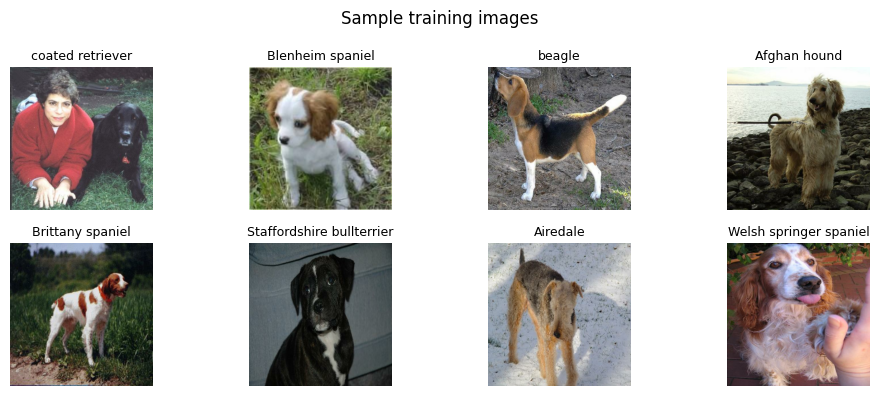

Training batches: 644
Validation batches: 129
Image shape: (256, 256, 3)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

class_names = train_data.class_names

plt.figure(figsize=(10, 4)) #creating a plotting window
for images, labels in train_data.take(1): #taking one batch form the dataset
    for i in range(8):
        plt.subplot(2, 4, i+1) #subplot of 2 rows 4 columns
        plt.imshow(images[i].numpy().astype("uint8"))#displaying image by converting to numpy and 0-255 image range
        breed_name = class_names[labels[i]].split("-")[-1]
        plt.title(breed_name.replace("_", " "), fontsize=9) #labling
        plt.axis("off")
plt.suptitle("Sample training images", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Training batches: {len(train_data)}")
print(f"Validation batches: {len(val_data_v1)}")
print(f"Image shape: {images[0].shape}")

**`note -: Dataset is clean and balanced no major imbalance handling problem to solve. `**

there will be 2 verions for baseline model :


1.  baseline version 1 : traning wihtout normalizing images
2.  baseline verion 2 : traning with normalizating images

baseline version 1:


In [ ]:
# Baseline v1 — no normalization -----

train_data_v1= keras.utils.image_dataset_from_directory(
    directory=path + "/images/Images",
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(128,128),
    validation_split=0.2,
    subset='training',
    seed=42
)

val_data_v1 = keras.utils.image_dataset_from_directory(
    directory=path + "/images/Images",
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(128,128),
    validation_split=0.2,
    subset='validation',
    seed=42
)


Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.


In [ ]:
print(len(train_data.class_names))

120


# Phase 2 — Baseline model


In [ ]:
model_v1= Sequential()

# layer 1 ------
# conv layer 1
# input layer shape = (128,128,3), kernel size = 3x3, filters = 32
# parameters = (kh*kw*cin + 1) * cout
# parameters = (3×3×3 + 1) × 32 = 896
model_v1.add(Conv2D(32, kernel_size=(3,3), padding='valid',
                 activation='relu', input_shape=(128,128,3)))

# output after conv layer 1 = (126,126,32)

# max pooling layer 1
# parameters = 0
model_v1.add(MaxPooling2D((2,2)))

# output after max pooling layer 1 = (63,63,32)


# layer 2------
# conv layer 2
# input shape = (63,63,32), kernel size = 3x3, filters = 64
# parameters = (3×3×32 + 1) × 64 = 18,496
model_v1.add(Conv2D(64, kernel_size=(3,3), padding='valid',
                 activation='relu'))

# output after conv layer 2 = (61,61,64)

# max pooling layer 2
# parameters = 0
model_v1.add(MaxPooling2D((2,2)))

# output after max pooling layer 2 = (30,30,64)


# layer 3-------
# conv layer 3
# input shape = (30,30,64), kernel size = 3x3, filters = 128
# parameters = (3×3×64 + 1) × 128 = 73,856
model_v1.add(Conv2D(128, kernel_size=(3,3), padding='valid',
                 activation='relu'))
# output after conv layer 3 = (28,28,128)

# max pooling layer 3
# parameters = 0
model_v1.add(MaxPooling2D((2,2)))

# output after max pooling layer 3 = (14,14,128)



# flatten layer-----
# converts (14,14,128) into 25088 neurons
# parameters = 0
model_v1.add(Flatten())
# output after flatten layer = (25088)


# dense layer 1-----
# input neurons = 25088
# output neurons = 128
# parameters = (25088 + 1) × 128 = 3,211,392
model_v1.add(Dense(128, activation='relu'))

# output after dense layer 1 = (128)


# output layer----
# input neurons = 128
# output neurons = 120
# parameters = (128 + 1) × 120 = 15,480
model_v1.add(Dense(120, activation='softmax'))

# final output shape = (120)


# compile model
model_v1.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_v1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 120)            │        15,480 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,320,120 (12.67 MB)

 Trainable params: 3,320,120 (12.67 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_v1 = model_v1.fit(train_data_v1, validation_data=val_data_v1, epochs=10)

Epoch 1/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 320s 615ms/step - accuracy: 0.0111 - loss: 5.8186 - val_accuracy: 0.0119 - val_loss: 4.7849
Epoch 2/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 322s 616ms/step - accuracy: 0.0134 - loss: 4.7972 - val_accuracy: 0.0119 - val_loss: 4.7808
Epoch 3/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 312s 605ms/step - accuracy: 0.0303 - loss: 4.6925 - val_accuracy: 0.0151 - val_loss: 4.8392
Epoch 4/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 321s 624ms/step - accuracy: 0.0675 - loss: 4.4700 - val_accuracy: 0.0126 - val_loss: 4.9740
Epoch 5/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 341s 660ms/step - accuracy: 0.1123 - loss: 4.2368 - val_accuracy: 0.0129 - val_loss: 5.4404
Epoch 6/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 384s 665ms/step - accuracy: 0.1630 - loss: 3.9704 - val_accuracy: 0.0112 - val_loss: 5.4834
Epoch 7/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 358s 618ms/step - accuracy: 0.2072 - loss: 3.7654 - val_accuracy: 0.0109 - val_loss: 5.8946
Epoch 8/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 339s 658ms/step - accuracy: 0.2505 -

baseline version 2:


In [ ]:
# Baseline v2 — normalization -----

train_data_v2 = keras.utils.image_dataset_from_directory(
    directory=path + "/images/Images",
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(128,128),
    validation_split=0.2,
    subset='training',
    seed=42
)

val_data_v2 = keras.utils.image_dataset_from_directory(
    directory=path + "/images/Images",
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(128,128),
    validation_split=0.2,
    subset='validation',
    seed=42
)

Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.


In [ ]:
#normlaizing data
def norm(image, label):
    image = tf.cast(image/255., tf.float32)
    return image, label

train_data_v2 = train_data_v2.map(norm)
val_data_v2 = val_data_v2.map(norm)

In [ ]:
model_v2= Sequential()

# layer 1 ------
# conv layer 1
# input layer shape = (128,128,3), kernel size = 3x3, filters = 32
# parameters = (kh*kw*cin + 1) * cout
# parameters = (3×3×3 + 1) × 32 = 896
model_v2.add(Conv2D(32, kernel_size=(3,3), padding='valid',
                 activation='relu', input_shape=(128,128,3)))

# output after conv layer 1 = (126,126,32)

# max pooling layer 1
# parameters = 0
model_v2.add(MaxPooling2D((2,2)))

# output after max pooling layer 1 = (63,63,32)


# layer 2------
# conv layer 2
# input shape = (63,63,32), kernel size = 3x3, filters = 64
# parameters = (3×3×32 + 1) × 64 = 18,496
model_v2.add(Conv2D(64, kernel_size=(3,3), padding='valid',
                 activation='relu'))

# output after conv layer 2 = (61,61,64)

# max pooling layer 2
# parameters = 0
model_v2.add(MaxPooling2D((2,2)))

# output after max pooling layer 2 = (30,30,64)


# layer 3-------
# conv layer 3
# input shape = (30,30,64), kernel size = 3x3, filters = 128
# parameters = (3×3×64 + 1) × 128 = 73,856
model_v2.add(Conv2D(128, kernel_size=(3,3), padding='valid',
                 activation='relu'))
# output after conv layer 3 = (28,28,128)

# max pooling layer 3
# parameters = 0
model_v2.add(MaxPooling2D((2,2)))

# output after max pooling layer 3 = (14,14,128)



# flatten layer-----
# converts (14,14,128) into 25088 neurons
# parameters = 0
model_v2.add(Flatten())
# output after flatten layer = (25088)


# dense layer 1-----
# input neurons = 25088
# output neurons = 128
# parameters = (25088 + 1) × 128 = 3,211,392
model_v2.add(Dense(128, activation='relu'))

# output after dense layer 1 = (128)


# output layer----
# input neurons = 128
# output neurons = 120
# parameters = (128 + 1) × 120 = 15,480
model_v2.add(Dense(120, activation='softmax'))

# final output shape = (120)


# compile model
model_v2.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │        15,480 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,320,120 (12.67 MB)

 Trainable params: 3,320,120 (12.67 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_v2 = model_v2.fit(train_data_v2, validation_data=val_data_v2, epochs=10)

Epoch 1/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 615s 1s/step - accuracy: 0.0198 - loss: 4.6625 - val_accuracy: 0.0326 - val_loss: 4.5086
Epoch 2/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 599s 1s/step - accuracy: 0.0573 - loss: 4.3025 - val_accuracy: 0.0469 - val_loss: 4.4207
Epoch 3/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 608s 1s/step - accuracy: 0.1122 - loss: 3.9101 - val_accuracy: 0.0612 - val_loss: 4.3621
Epoch 4/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 612s 1s/step - accuracy: 0.2348 - loss: 3.2200 - val_accuracy: 0.0593 - val_loss: 4.9266
Epoch 5/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 622s 1s/step - accuracy: 0.4280 - loss: 2.2808 - val_accuracy: 0.0593 - val_loss: 6.1194
Epoch 6/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 580s 1s/step - accuracy: 0.6317 - loss: 1.4154 - val_accuracy: 0.0515 - val_loss: 8.4574
Epoch 7/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 571s 1s/step - accuracy: 0.7696 - loss: 0.8666 - val_accuracy: 0.0517 - val_loss: 10.6506
Epoch 8/10
515/515 ━━━━━━━━━━━━━━━━━━━━ 583s 1s/step - accuracy: 0.8413 - loss: 0.5723 - val_acc

In [ ]:
# ── Results Summary — Notebook 1 ──

import pandas as pd

results_nb1 = {
    "  Experiment ": [
        "Baseline v1 (No Normalization)",
        "Baseline v2 (With Normalization)"
    ],
    "  Validation Accuracy ": [
        "1.70%",
        "5.27%"
    ],
    "  Training Accuracy ": [
        "32.41%",
        "90.96%"
    ],
    " Final Validation Loss ": [
        "74.87",
        "15.48"
    ],
    "   Key Observation   ": [
        "Initial loss = 51.3  :- unstable optimization without normalization",
        "Initial loss = 4.8 (~91% lower):- stable training but severe overfitting"
    ]
}

df = pd.DataFrame(results_nb1)

display(
    df.style
      .set_caption("📊 Notebook 1 Results Summary")
      .hide(axis="index")
      .set_properties(**{
          "text-align": "left",
          "white-space": "normal"
      })
)

Experiment,Validation Accuracy,Training Accuracy,Final Validation Loss,Key Observation
Baseline v1 (No Normalization),1.70%%,32.41%,74.87,Initial loss = 51.3 :- unstable optimization without normalization
Baseline v2 (With Normalization),5.27%%,90.96%,15.48,Initial loss = 4.8 (~91% lower):- stable training but severe overfitting


Takeaways

• *Normalization reduced the initial loss from ~51 to ~4.7.*

• *Validation accuracy improved from 1.7% to 5.3%.*

• *Training became substantially more stable.*

• *Severe overfitting remained, motivating later experiments.*

Baseline to beat: **5.27% val accuracy**
All future notebooks will be judged against this number.